In [1]:
from matplotlib import pyplot as plt
import numpy as np
import time as TIME

import json

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
coSimsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Cotrsc/'
postSimsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Posttrsc/'

In [4]:
geneListFile = '../multiIsoformGenes.txt'
with open(geneListFile, 'r') as f:
    geneList = [line.rstrip() for line in f]
len(geneList)

12025

In [5]:
coData = {}
noData = {}

startTime = TIME.time()

for gene in geneList:
    coFile = f'{coSimsDir}json/{gene}.json'
    with open(coFile, 'rb') as handle:
        geneDat = json.load(handle)
        coData[gene] = geneDat[gene]
        
    noFile = f'{postSimsDir}json/{gene}.json'
    with open(noFile, 'rb') as handle:
        geneDat = json.load(handle)
        noData[gene] = geneDat[gene]
        
        if geneList.index(gene) % 1000 == 0:
            print(geneList.index(gene), f': Total Time Elapsed {TIME.time()-startTime}')

0 : Total Time Elapsed 0.0002067089080810547
1000 : Total Time Elapsed 0.023546695709228516
2000 : Total Time Elapsed 0.05183815956115723
3000 : Total Time Elapsed 0.08684253692626953
4000 : Total Time Elapsed 0.127821683883667
5000 : Total Time Elapsed 0.1752946376800537
6000 : Total Time Elapsed 0.23076534271240234
7000 : Total Time Elapsed 0.29387688636779785
8000 : Total Time Elapsed 0.36283206939697266
9000 : Total Time Elapsed 0.44412660598754883
10000 : Total Time Elapsed 0.5333609580993652
11000 : Total Time Elapsed 0.6313974857330322
12000 : Total Time Elapsed 0.7383043766021729


In [6]:
coSumm = {}
coSumm['errors'] = []
coSumm['noSim'] = []
coSumm['failedSplice'] = []
coSumm['incomplete'] = []
coSumm['allIsoforms'] = []
coSumm['allMrnaMade'] = []

for gene, summ in coData.items():
    # print(gene)

    # try:
    if 'noSim' in summ:
        coSumm['noSim'].append(gene)
        continue

    if 'Error' in summ:
        coSumm['errors'].append(gene)
        continue
    
    if 'FailedSplice' in summ:
        if summ['mrnaMade'] == 0:
            coSumm['failedSplice'].append(gene)
            # continue
        else:
            coSumm['incomplete'].append(gene)

    if 'isoforms' in summ:
        coSumm['allIsoforms'].append(summ['isoforms'])
        # if summ['isoforms'] == 1:
        #     print(gene)
    if 'mrnaMade' in summ:
        coSumm['allMrnaMade'].append(summ['mrnaMade'])
        if summ['mrnaMade'] == 0:
            print(gene)

    # except:
    #     print(gene)

print(len(coSumm['errors']))
print(len(coSumm['noSim']))
print(len(coSumm['failedSplice']))
print(len(coSumm['incomplete']))
print(len(coSumm['allIsoforms']))
print(len(coSumm['allMrnaMade']))

TMEM9
SRSF11
GABPB2
DRAM2
TMED5
MKNK1
LEPROT
LOC101929147
NVL
AZIN2
VPS45
GAS5
CAPZB
ST3GAL3
ZNF692
SLC44A5
ADAM15
RCOR3
TRIM46
PRKACB
ARNT
ARV1
PTPRU
RHD
RAP1GAP
OSCP1
PRKCZ
CHRM3
MSTO1
SHISAL2A
PRPF38B
EIF4G3
DCAF6
MORN1
MINOS1
OBSCN
SYT14
ODF2L
CEPT1
RGS7
RPS6KC1
OSBPL9
C1orf61
CCDC30
C1orf141
COL24A1
LOC103091866
AGBL4
SLC44A3
CHIA
MECR
IL12RB2
YY1AP1
UCHL5
NIPAL3
SLC50A1
ZMYM4
CHD1L
SLC35E2A
DFFB
EPB41
MR1
FGGY
MEAF6
SNAP47
NBPF8
CRYZL2P-SEC16B
CSMD2
ADGRL2
DPH2
PTPRF
NFASC
CDC42
MROH7-TTC4
ST6GALNAC3
SPATA21
AXDND1
TSEN15
SNX7
C8B
ELMOD3
SP140L
C2orf42
LCLAT1
PUM2
MGAT4A
TAF1B
BMS1P14
BIN1
IL18R1
ACVR1
ITSN2
DGUOK
WDPCP
ZRANB3
BABAM2
ATAD2B
REV1
AHSA2P
CLHC1
MAP4K4
SLC4A10
SFXN5
ABI2
ACMSD
STEAP3
PPIL3
KYNU
HPCAL1
KANSL3
ANXA4
KIDINS220
RABL2A
TTN
TFPI
MAP2
ZNF385B
ADGRF3
LRRFIP1
LPIN1
RPE
HDLBP
TIA1
CCDC138
PMS1
SCN1A
LNPK
MYO3B
PLEKHB2
GTDC1
CLASP1
FHL2
DAW1
VRK2
VWA3B
TANC1
COLEC11
MBOAT2
RPL23AP7
IL1RL2
KIF1A
LINC01881
THUMPD2
BOLL
CASP8
SLC38A11
NEK11
ABI3BP
CCDC14
MLH1
TPRA

In [7]:
noSumm = {}
noSumm['errors'] = []
noSumm['noSim'] = []
noSumm['failedSplice'] = []
noSumm['incomplete'] = []
noSumm['allIsoforms'] = []
noSumm['allMrnaMade'] = []

incompletes = []

for gene, summ in noData.items():

    if 'noSim' in summ:
        noSumm['noSim'].append(gene)
        continue

    if 'Error' in summ:
        noSumm['errors'].append(gene)
        continue
    
    if 'FailedSplice' in summ:
        if summ['mrnaMade'] == 0:
            noSumm['failedSplice'].append(gene)
            # print(gene)
            # continue
        else:
            noSumm['incomplete'].append(gene)
            incompletes.append(summ['mrnaMade'])

    if 'isoforms' in summ:
        noSumm['allIsoforms'].append(summ['isoforms'])
        # if summ['isoforms'] == 1:
        #     print(gene)
    if 'mrnaMade' in summ:
        noSumm['allMrnaMade'].append(summ['mrnaMade'])
        if summ['mrnaMade'] == 0:
            print(gene)

print(len(noSumm['errors']))
print(len(noSumm['noSim']))
print(len(noSumm['failedSplice']))
print(len(noSumm['incomplete']))
print(len(noSumm['allIsoforms']))
print(len(noSumm['allMrnaMade']))

SRSF11
DRAM2
CRB1
MKNK1
NVL
AZIN2
VPS45
GAS5
ST3GAL3
SLC44A5
ADAM15
RCOR3
PRKACB
ARNT
SGIP1
RAP1GAP
CHRM3
MSTO1
SHISAL2A
EIF4G3
MINOS1
SYT14
ODF2L
RPS6KC1
C1orf61
CCDC30
COL24A1
ITGB3BP
LOC103091866
PTBP2
AGBL4
MECR
YY1AP1
NIPAL3
MUTYH
DFFB
EPB41
MR1
FGGY
MEAF6
DNM3
SNAP47
NBPF8
TDRD5
CRYZL2P-SEC16B
CSMD2
ATXN7L2
ADGRL2
SCMH1
DPH2
PTPRF
NFASC
NBPF3
KCNT2
SPATA21
AXDND1
TSEN15
TMEM183A
MFSD9
ELMOD3
LCLAT1
THADA
MGAT4A
BIN1
ZRANB3
CLHC1
MAP4K4
INPP4A
SFXN5
ABI2
ACMSD
KANSL3
KIDINS220
RABL2A
HECW2
MAP2
ZNF385B
LRRFIP1
RPE
HDLBP
TIA1
CCDC138
SCN1A
ITGB1BP1
GTDC1
ERBB4
CLASP1
FHL2
VWA3B
DNAJC10
COLEC11
MBOAT2
LINC01881
THUMPD2
SPAG16
CASP8
NEK11
ABI3BP
CCDC14
CIDEC
LSAMP
CLASP2
FBXL2
ROBO2
SIDT1
CADPS
MFSD1
ANO10
ZNF148
PFKFB4
RAF1
ITPR1
GHRLOS
CCDC66
GRM7
ZBBX
STXBP5L
KLHL24
TNK2
FAM19A1
TAMM41
B3GALNT1
THRB
ZDHHC3
LEKR1
ERC2
MCCC1
FHIT
EXOG
ATP2B2
PXK
IQCJ-SCHIP1
LRRFIP2
CBLB
ZBTB38
CMC1
MBNL1
ARL6
WDR48
NME9
PBRM1
TTLL3
OPA1
GRID2
ADGRL3
ANK2
ANAPC10
PRMT9
ABLIM2
PAQR3
GNPDA2
SORBS2
GUCY

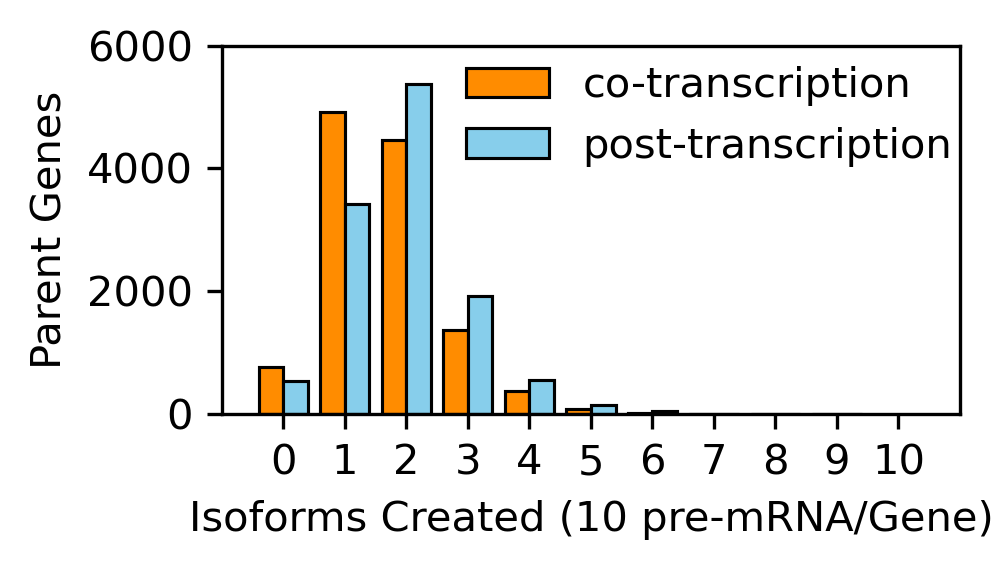

In [8]:
# plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({"font.family": 'sans-serif'})

# plt.rcParams['figure.dpi'] = 300

# plt.figure(figsize=(3.3,2))
fig = plt.figure(figsize=(3.4,2))

ax = plt.gca()

bins = [x-0.5 for x in range(0,11)]
ax.hist([coSumm['allMrnaMade'], noSumm['allMrnaMade']], 
        color=['darkorange','skyblue'], edgecolor='k', linewidth=0.75, bins=bins, label=['co-transcription', 'post-transcription'])

ax.set_xlim(-1,11)
ax.set_ylim(0,6000)
ax.set_ylabel('Parent Genes')
ax.set_xlabel('Isoforms Created (10 pre-mRNA/Gene)')

# ax.set_yscale('log')

ax.xaxis.set_ticks(np.array([0,1,2,3,4,5,6,7,8,9,10]))

ax.legend(frameon=False, bbox_to_anchor=(0.28,0.57))

# fig.set_dpi(300)
# ax.set_yscale('log')
plt.tight_layout()

plt.savefig('./multi_gene_isoforms_co_vs_post.png', transparent=True)